# Synthetic Ground-Truth Training — Nelder-Mead Baseline

Derivative-free benchmark using Nelder-Mead simplex optimization.
Same setup as the gradient-based Guarino notebook for direct comparison.

**Key differences from gradient-based approach:**
- No surrogate gradients needed (forward simulation only)
- No sigmoid reparameterization (bounds enforced by clipping in objective)
- Uses coincidence factor (Γ) as objective — discrete but directly meaningful
- Typically requires more function evaluations but each is cheaper (no backward pass)

In [1]:
import logging
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config
from scipy.optimize import minimize

from ADoptEX.core.data import TraceData, crop_to_stim_window, load_trace
from ADoptEX.core.parameters import NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import VanRossumLossConfig, van_rossum_distance
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_stim_window_plot,
)
from ADoptEX.training import TrainingResult

import warnings
warnings.filterwarnings("ignore", message="The AdEx channel does not support surrogate gradients")
logging.getLogger("jaxley").setLevel(logging.WARNING)

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

SEED = 42

## 1. Ground Truth Parameters & Current Stimulus

In [2]:
# --- Load experimental current waveform (we only use the current, not the voltage) ---
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

exp_trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)
exp_cropped = crop_to_stim_window(exp_trace, max_duration_ms=195.0, padding_ms_before=5)

print(f"Current waveform: {exp_cropped.n_samples} samples, dt={exp_cropped.dt_ms:.3f} ms")
print(f"Stim window: idx {exp_cropped.stim_start_idx} - {exp_cropped.stim_end_idx} ({exp_cropped.stim_duration_ms:.1f} ms)")
print(f"Stim current: {exp_cropped.stim_current_pA:.1f} pA")

Current waveform: 2000 samples, dt=0.100 ms
Stim window: idx 50 - 2000 (195.0 ms)
Stim current: 421.3 pA


In [3]:
# --- Ground truth parameters (change this to test different regimes) ---
GROUND_TRUTH_BASE = "tonic"  # "tonic", "adaptation", or "original"

ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])

for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        ground_truth_params[k] = bounds.clip(v)

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
print("Ground truth parameters:")
for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        pos = (v - bounds.min) / (bounds.max - bounds.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{bounds.min}, {bounds.max}]  ({pos:.0f}% into range)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: tonic
Ground truth parameters:
  C_m             200.000  [180.0, 220.0]  (50% into range)
  g_L              10.000  [9.0, 13.0]  (25% into range)
  E_L             -70.000  [-75.0, -68.0]  (71% into range)
  v_T             -50.000  [-60.0, -30.0]  (33% into range)
  delta_T           2.000  [2, 20.0]  (0% into range)
  v_reset         -58.000  [-60.0, -45.0]  (13% into range)
  v_threshold       0.000  [-20.0, 30.0]  (40% into range)
  tau_w            30.000  [20.0, 320.0]  (3% into range)
  a                 2.000  [-10.0, 3.0]  (92% into range)
  b                 0.000  [0.0, 65.0]  (0% into range)
  I               500.000


## 2. Generate Synthetic Voltage Trace

INFO:2026-03-20 14:15:46,376:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Ground truth simulation: 15 spikes, 75.0 Hz

Synthetic TraceData: 2000 samples, 15 spikes
Spike times: [ 22.6  34.4  46.5  58.9  71.4  84.   96.7 109.4 122.2 135.  147.8 160.6
 173.4 186.2 199. ] ms


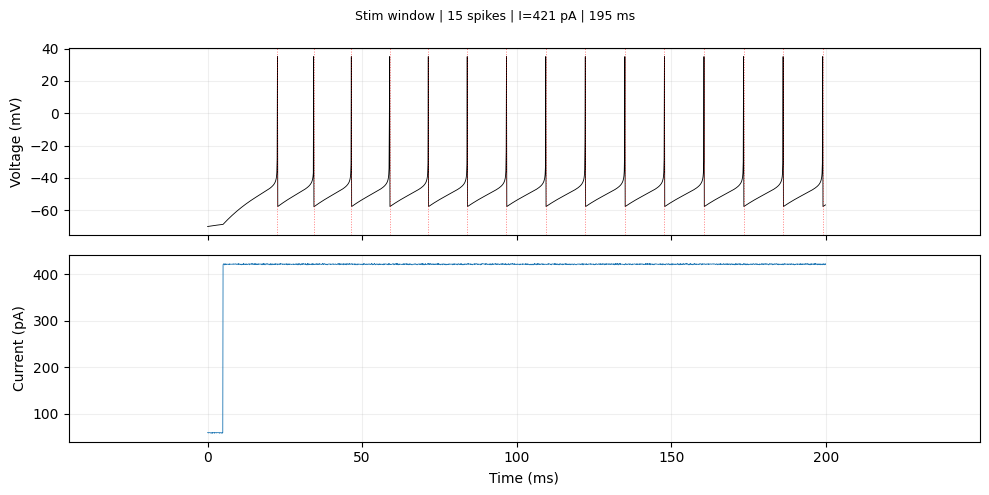

In [4]:
# --- Simulate ground truth ---
# Use use_surrogate=False for Nelder-Mead: no backward pass needed,
# and we want the standard AdEx forward dynamics.
sim_gt = simulate_with_current_trace(
    params=ground_truth_params,
    current_trace_pA=exp_cropped.current, v_init=exp_cropped.voltage[0],
    dt_ms=exp_cropped.dt_ms,
    use_surrogate=False,
)

print(f"Ground truth simulation: {sim_gt.n_spikes} spikes, {sim_gt.firing_rate_hz:.1f} Hz")

# --- Package as TraceData ---
n = len(exp_cropped.time)
voltage_gt = sim_gt.voltage[:n].copy()
spike_times = sim_gt.spike_times

SPIKE_PEAK_MV = 35.0
for st in spike_times:
    idx = int(st / exp_cropped.dt_ms)
    if 0 <= idx < len(voltage_gt):
        voltage_gt[idx] = SPIKE_PEAK_MV

data = TraceData(
    time=exp_cropped.time,
    voltage=voltage_gt,
    current=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    spike_times=spike_times,
    stim_start_idx=exp_cropped.stim_start_idx,
    stim_end_idx=exp_cropped.stim_end_idx,
    stim_current_pA=exp_cropped.stim_current_pA,
)

print(f"\nSynthetic TraceData: {data.n_samples} samples, {data.n_spikes} spikes")
print(f"Spike times: {data.spike_times.round(1)} ms")

trace_stim_window_plot(data);

## 3. Perturbed Initial Parameters

In [5]:
PERTURBATION = 0.25  # relative perturbation

TRAINABLE_STAGE1 = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T", "a", "b", "tau_w"]

def perturb_params(
    params: dict,
    trainable: list[str],
    perturbation: float,
    key: jax.Array,
) -> dict:
    """Add relative noise to trainable params, clipping to PARAM_BOUNDS."""
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed


all_trainable = list(set(TRAINABLE_STAGE1))
initial_params = perturb_params(
    ground_truth_params, all_trainable, PERTURBATION, jr.PRNGKey(SEED)
)

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(init - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err_pct:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
b                   0.000        0.983     1.5%
E_L               -70.000      -69.203    11.4%
v_T               -50.000      -47.491     8.4%
v_reset           -58.000      -58.832     5.5%
tau_w              30.000       66.561    12.2%
C_m               200.000      198.285     4.3%
a                   2.000        1.347     5.0%
delta_T             2.000        3.022     5.7%
g_L                10.000       10.114     2.9%


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 11 spikes (target: 15)
Gamma = 0.032


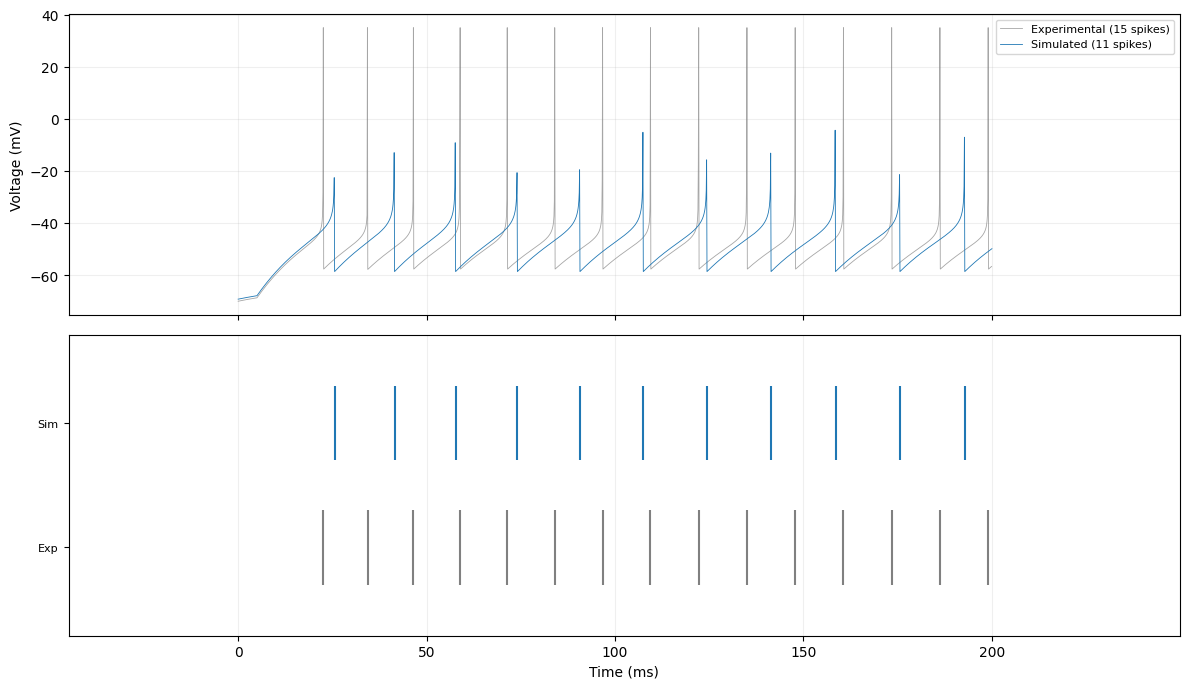

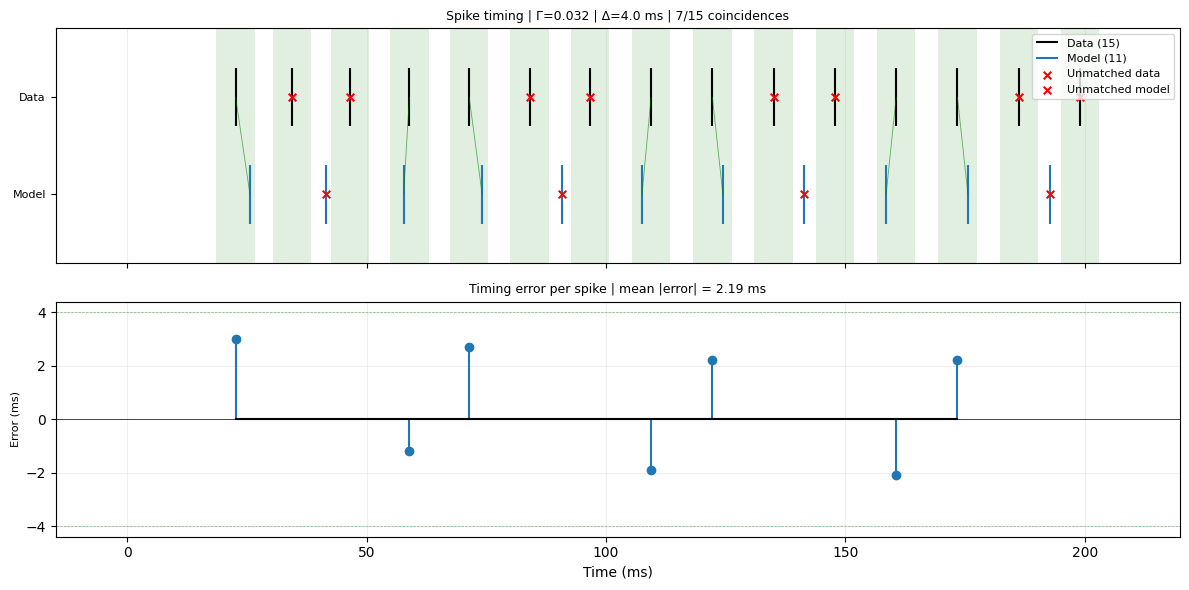

In [6]:
# Simulate with perturbed initial parameters to see the starting point
sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")

if sim_init.n_spikes > 0 and data.n_spikes > 0:
    cf_s0 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_init.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=4,
    )
    print(f"Gamma = {cf_s0.gamma:.3f}")
else:
    cf_s0 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_init);

if cf_s0 is not None:
    spike_timing_plot(data, sim_init, cf_s0);

## 4. Nelder-Mead Optimization

Derivative-free simplex method. Objective: Van Rossum distance between spike trains.
Evaluates coincidence factor (Γ) for comparison with gradient-based results.

In [7]:
PARAM_ORDER = TRAINABLE_STAGE1

# Van Rossum config
vr_config = VanRossumLossConfig(tau_ms=15.0, subthreshold_clamp_mv=-40, weight_subthreshold=0.5)

# Build target spike train from ground truth simulation
exp_spike_train = jnp.array(sim_gt.spikes[:data.stim_end_idx])

print(f"Target spike train: {int(exp_spike_train.sum())} spikes in {len(exp_spike_train)} timesteps")

# Bounds for scipy
bounds_list = [(PARAM_BOUNDS[k].min, PARAM_BOUNDS[k].max) for k in PARAM_ORDER]


def params_to_vector(params: dict, order: list[str]) -> np.ndarray:
    return np.array([params[k] for k in order])


def vector_to_params(x: np.ndarray, base_params: dict, order: list[str]) -> dict:
    params = dict(base_params)
    for i, k in enumerate(order):
        params[k] = float(x[i])
    return params


# Track evaluation history
eval_history = []


def objective(x: np.ndarray) -> float:
    params = vector_to_params(x, initial_params, PARAM_ORDER)

    sim = simulate_with_current_trace(
        params=params,
        current_trace_pA=data.current, v_init=data.voltage[0],
        dt_ms=data.dt_ms,
        use_surrogate=False,
    )

    sim_spikes = jnp.array(sim.spikes[:data.stim_end_idx])
    loss = float(van_rossum_distance(sim_spikes, exp_spike_train, data.dt_ms, vr_config))

    eval_history.append(loss)
    return loss


x0 = params_to_vector(initial_params, PARAM_ORDER)
print(f"Initial objective: {objective(x0):.4f}")
print(f"x0 = {x0}")

Target spike train: 15 spikes in 2000 timesteps
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial objective: 3.0530
x0 = [198.28519106  10.11437893 -58.83240926 -47.49139071 -69.20317519
   3.02214265   1.34734672   0.98347604  66.56094074]


In [8]:
eval_history = []  # reset

t0 = time.time()
result_nm = minimize(
    objective,
    x0,
    method="Nelder-Mead",
    bounds=bounds_list,
    options={
        "maxiter": 500,
        "maxfev": 2000,
        "xatol": 1e-4,
        "fatol": 1e-6,
        "disp": True,
        "adaptive": True,
    },
)
total_time = time.time() - t0

print(f"\nNelder-Mead complete.")
print(f"  Success:     {result_nm.success}")
print(f"  Message:     {result_nm.message}")
print(f"  Best loss:   {result_nm.fun:.4f}")
print(f"  Evaluations: {result_nm.nfev}")
print(f"  Iterations:  {result_nm.nit}")
print(f"  Total time:  {total_time:.1f} s")
print(f"  Time/eval:   {total_time / result_nm.nfev * 1000:.1f} ms")

# Extract best parameters
best_params_nm = vector_to_params(result_nm.x, initial_params, PARAM_ORDER)

print(f"\n{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Recovered':>12}")
print("-" * 52)
for k in PARAM_ORDER:
    gt = ground_truth_params[k]
    init = initial_params[k]
    rec = best_params_nm[k]
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {rec:>12.3f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recor

KeyboardInterrupt: 

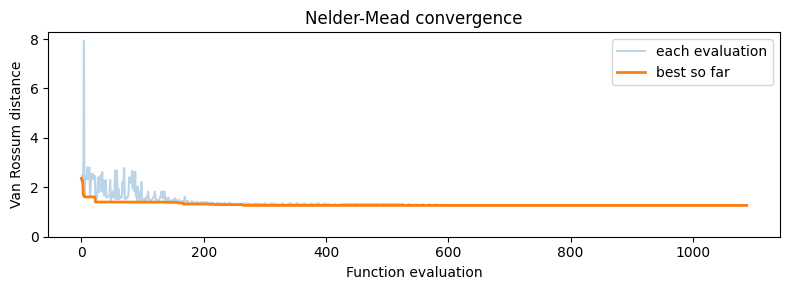

In [9]:
import matplotlib.pyplot as plt

# Plot convergence: best loss seen so far at each evaluation
best_so_far = np.minimum.accumulate(eval_history)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(eval_history, alpha=0.3, label="each evaluation")
ax.plot(best_so_far, color="C1", linewidth=2, label="best so far")
ax.set_xlabel("Function evaluation")
ax.set_ylabel("Van Rossum distance")
ax.set_title("Nelder-Mead convergence")
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

Nelder-Mead: 14 spikes (target: 15)
Gamma = 0.872


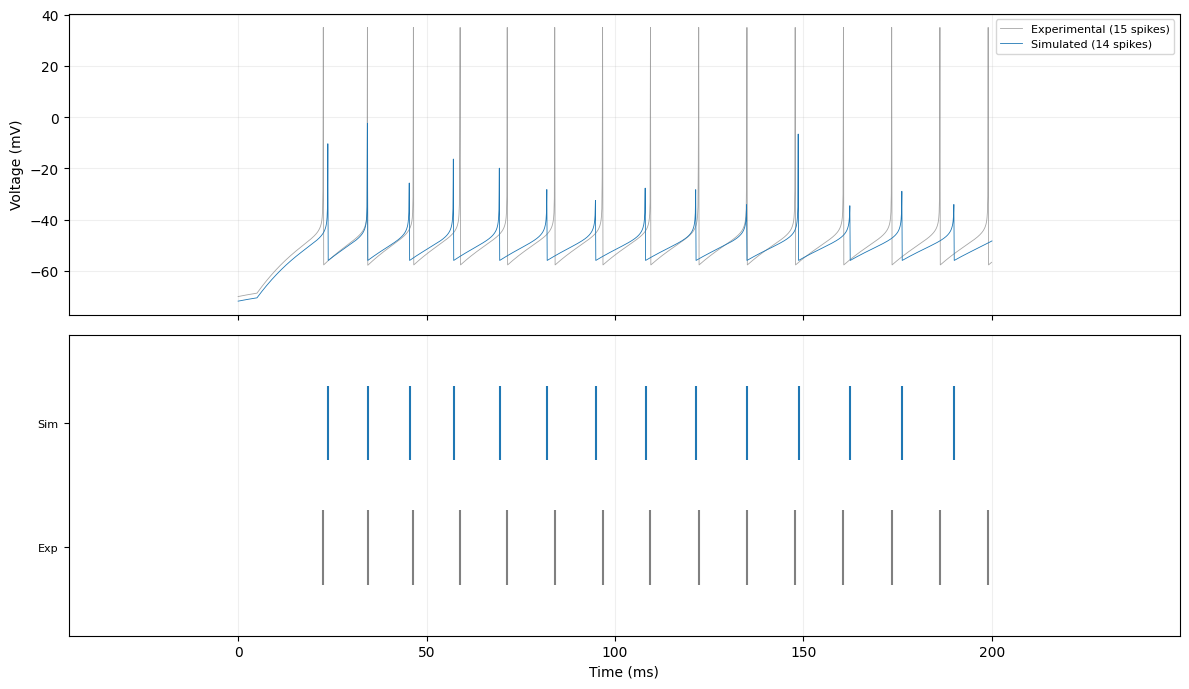

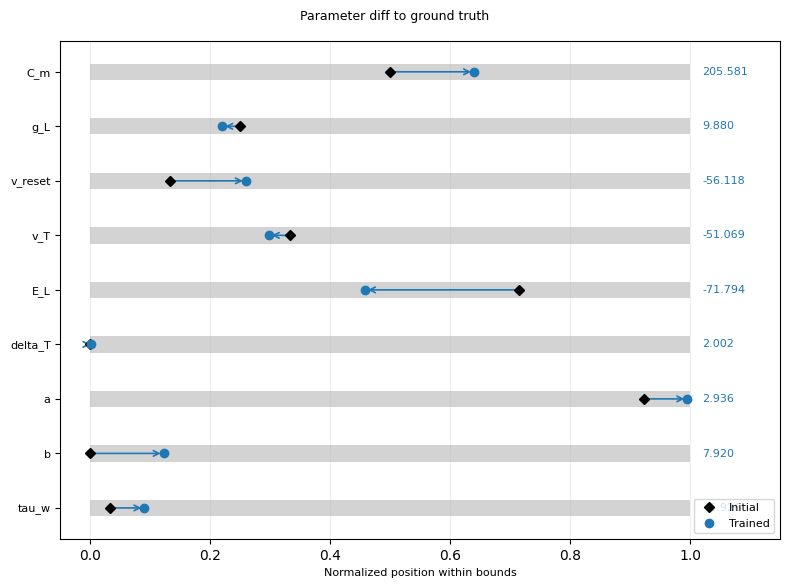

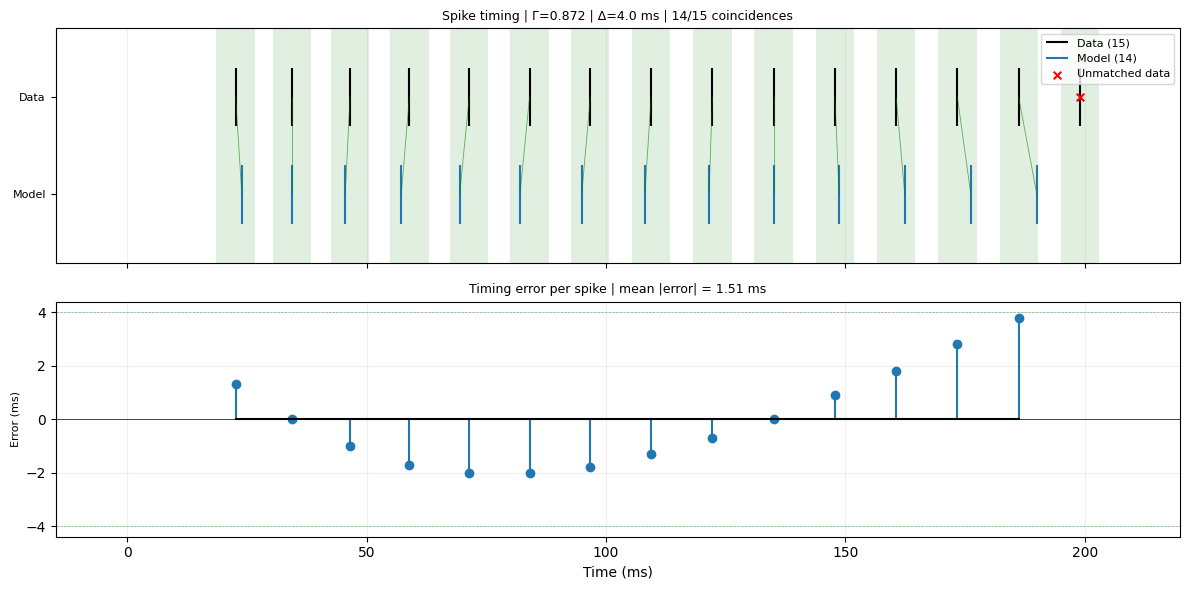

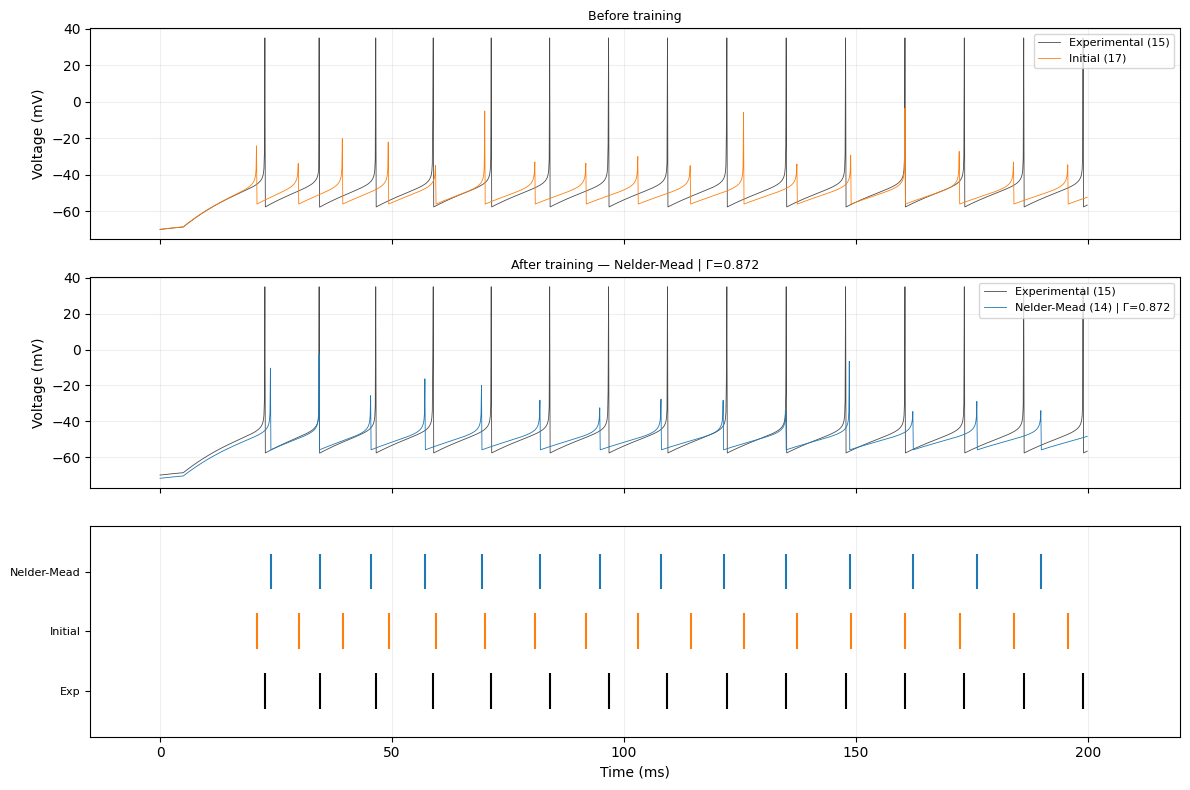

In [10]:
# Evaluate
sim_nm = simulate_with_current_trace(
    params=best_params_nm,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Nelder-Mead: {sim_nm.n_spikes} spikes (target: {data.n_spikes})")

if sim_nm.n_spikes > 0 and data.n_spikes > 0:
    cf_nm = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_nm.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=4,
    )
    print(f"Gamma = {cf_nm.gamma:.3f}")
else:
    cf_nm = None
    print("Gamma: N/A (no spikes)")

# Build a TrainingResult for parameter_comparison_plot compatibility
# Convert recovered params to Jaxley trainable format
trainable_params_nm = []
for k in PARAM_ORDER:
    if k == "C_m":
        trainable_params_nm.append({"capacitance": jnp.array([best_params_nm[k]])})
    else:
        trainable_params_nm.append({f"AdEx_{k}": jnp.array([best_params_nm[k]])})

result_stage1 = TrainingResult(
    trainable_params=trainable_params_nm,
    loss_history=eval_history,
    time_per_epoch=[total_time / len(eval_history)] * len(eval_history),
    initial_params=initial_params,
    label=f"Nelder-Mead ({result_nm.nfev} evals)",
)

fit_comparison_plot(data, sim_nm)

parameter_comparison_plot(TrainingResult(
    trainable_params=trainable_params_nm,
    loss_history=eval_history,
    time_per_epoch=[total_time / len(eval_history)] * len(eval_history),
    initial_params=ground_truth_params,
), figtitle="Parameter diff to ground truth");

if cf_nm is not None:
    spike_timing_plot(data, sim_nm, cf_nm);

fit_before_after_plot(
    data,
    sim_init,
    [sim_nm],
    coincidence=[cf_nm],
    labels=["Nelder-Mead"],
);